In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/crime_feature_engineered.csv")

print(df.shape)

(492933, 37)


In [2]:
geo_features = [
    'Latitude_Scaled',
    'Longitude_Scaled'
]

X_geo = df[geo_features]

In [3]:
from sklearn.preprocessing import StandardScaler

X_geo = StandardScaler().fit_transform(X_geo)

In [4]:
from sklearn.cluster import KMeans
import plotly.express as px

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10        
    )

    km.fit(X_geo)

    inertia.append(km.inertia_)

elbow_df = pd.DataFrame({
    "K": range(2,11),
    "Inertia": inertia
})

fig = px.line(
    elbow_df,
    x="K",
    y="Inertia",
    markers=True,
    title="Elbow Method for K-Means"
)

fig.show()

In [5]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_geo)

In [6]:
sample_df = df.sample(10000)

fig = px.scatter_mapbox(
    sample_df,
    lat='Latitude',
    lon='Longitude',
    color='KMeans_Cluster',
    zoom=9,
    height=700,
    title="K-Means Crime Hotspots"
)

fig.update_layout(
    mapbox_style="open-street-map"
)

fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13028\2384778121.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.05,
    min_samples=50
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_geo)

In [8]:
print(
    df['DBSCAN_Cluster']
    .value_counts()
)

DBSCAN_Cluster
 0     483907
 2       2636
 4       1525
-1       1028
 3       1009
 5        888
 1        863
 14       189
 16       125
 11       118
 13       110
 12       109
 8         83
 6         79
 10        77
 7         72
 9         61
 15        54
Name: count, dtype: int64


In [9]:
sample_df = df.sample(10000)

fig = px.scatter_mapbox(
    sample_df,
    lat='Latitude',
    lon='Longitude',
    color='DBSCAN_Cluster',
    zoom=9,
    height=700,
    title="DBSCAN Crime Hotspots"
)

fig.update_layout(
    mapbox_style='open-street-map'
)

fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13028\3670897969.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [10]:
from sklearn.cluster import AgglomerativeClustering

X_geo = df[
    ['Latitude_Scaled','Longitude_Scaled']
]

sample_geo = X_geo.sample(
    10000,
    random_state=42
)

hc = AgglomerativeClustering(
    n_clusters=8
)

hc_labels = hc.fit_predict(
    sample_geo
)

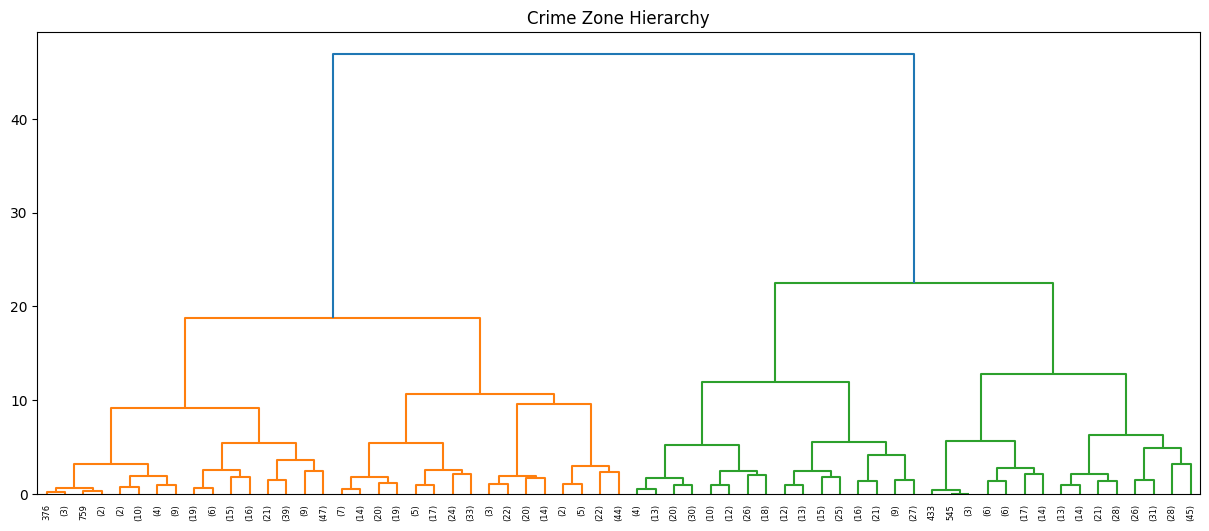

In [11]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

sample_small = sample_geo.sample(1000)

linked = linkage(
    sample_small,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title(
    "Crime Zone Hierarchy"
)

plt.show()

In [12]:
#Evaluation

In [13]:
sample_eval = df.sample(
    10000,
    random_state=42
)

X_eval = sample_eval[
    ['Latitude_Scaled','Longitude_Scaled']
]

labels_eval = sample_eval['KMeans_Cluster']


In [14]:
sample_geo = X_geo.sample(
    10000,
    random_state=42
)

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2,11):
    for init in ['k-means++', 'random']:
        for n_init in [10, 20, 50]:
            for max_iter in [300, 500]:

                km = KMeans(
                    n_clusters=k,
                    init=init,
                    n_init=n_init,
                    max_iter=max_iter,
                    random_state=42
                )

                labels = km.fit_predict(sample_geo)

                score = silhouette_score(
                    sample_geo,
                    labels
                )

                results.append([
                    k,
                    init,
                    n_init,
                    max_iter,
                    score
                ])

results_df = pd.DataFrame(
    results,
    columns=[
        'K',
        'Init',
        'N_Init',
        'Max_Iter',
        'Silhouette'
    ]
)

results_df.sort_values(
    'Silhouette',
    ascending=False
).head()

,K,Init,N_Init,Max_Iter,Silhouette
6,2,random,10,300,0.469981
7,2,random,10,500,0.469981
0,2,k-means++,10,300,0.469563
1,2,k-means++,10,500,0.469563
3,2,k-means++,20,500,0.469563


In [16]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_eval,
    labels_eval
)

print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.4003


In [17]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_eval,
    labels_eval
)

print("Davies-Bouldin Score:", round(db_score,4))

Davies-Bouldin Score: 0.7928


In [18]:
dbscan_labels = df['DBSCAN_Cluster']

In [19]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

eval_df = sample_eval.copy()

eval_df['DBSCAN_Cluster'] = (
    df.loc[eval_df.index, 'DBSCAN_Cluster']
)

eval_df = eval_df[
    eval_df['DBSCAN_Cluster'] != -1
]

X_db = eval_df[
    ['Latitude_Scaled','Longitude_Scaled']
]

labels_db = eval_df['DBSCAN_Cluster']

db_sil = silhouette_score(
    X_db,
    labels_db
)

db_dbi = davies_bouldin_score(
    X_db,
    labels_db
)

print("DBSCAN Silhouette:", round(db_sil,4))
print("DBSCAN Davies-Bouldin:", round(db_dbi,4))

DBSCAN Silhouette: -0.4007
DBSCAN Davies-Bouldin: 0.5843


In [20]:
sample_geo = X_geo.sample(
    10000,
    random_state=42
)

In [21]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=8
)

hc_labels = hc.fit_predict(
    sample_geo
)

hc_sil = silhouette_score(
    sample_geo,
    hc_labels
)

hc_dbi = davies_bouldin_score(
    sample_geo,
    hc_labels
)

print("Hierarchical Silhouette:", round(hc_sil,4))
print("Hierarchical Davies-Bouldin:", round(hc_dbi,4))

Hierarchical Silhouette: 0.3653
Hierarchical Davies-Bouldin: 0.8067


In [22]:
# KMeans
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_geo)

# DBSCAN
dbscan = DBSCAN(
    eps=0.05,
    min_samples=50
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_geo)

# Save updated dataset
df.to_csv(
    "../data/crime_feature_engineered.csv",
    index=False
)

print("Cluster columns saved successfully")

Cluster columns saved successfully


In [23]:
sample_geo = X_geo.sample(
    10000,
    random_state=42
)

hc = AgglomerativeClustering(
    n_clusters=8
)

sample_geo['Hierarchical_Cluster'] = hc.fit_predict(sample_geo)

sample_geo.to_csv(
    "../data/hierarchical_results.csv",
    index=False
)

In [24]:
hier_df = pd.read_csv("../data/hierarchical_results.csv")

In [25]:
#Temporal Pattern Clustering

In [26]:
from sklearn.preprocessing import LabelEncoder

day_encoder = LabelEncoder()

df['Day_Encoded'] = day_encoder.fit_transform(
    df['DayOfWeek']
)

X_time = df[
    ['Hour','Day_Encoded','Month']
]

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_time_scaled = scaler.fit_transform(
    X_time
)

In [28]:
from sklearn.cluster import KMeans
import plotly.express as px

inertia = []

for k in range(2,8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_time_scaled)

    inertia.append(km.inertia_)

elbow_df = pd.DataFrame({
    'K': range(2,8),
    'Inertia': inertia
})

fig = px.line(
    elbow_df,
    x='K',
    y='Inertia',
    markers=True,
    title='Temporal Clustering Elbow Method'
)

fig.show()

In [29]:
kmeans_time = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Time_Cluster'] = (
    kmeans_time.fit_predict(
        X_time_scaled
    )
)

In [30]:
profile = (
    df.groupby('Time_Cluster')
      .agg({
          'Hour':'mean',
          'Month':'mean',
          'Day_Encoded':'mean'
      })
      .reset_index()
)

profile

,Time_Cluster,Hour,Month,Day_Encoded
0,0,15.393040,3.351918,4.453434
1,1,16.312853,6.564015,0.881355
2,2,15.671149,9.654634,4.479181
3,3,3.057736,6.775991,2.685460


In [31]:
df['Time_Cluster'].value_counts()

Time_Cluster
1    151528
2    118978
0    117016
3    105411
Name: count, dtype: int64

In [32]:
import plotly.express as px

temp_summary = (
    df.groupby('Time_Cluster')
      .agg({
          'Hour':'mean',
          'Month':'mean'
      })
      .reset_index()
)

fig = px.scatter(
    temp_summary,
    x='Hour',
    y='Month',
    color='Time_Cluster',
    size=[100]*len(temp_summary),
    title='Temporal Crime Profiles'
)

fig.show()

In [33]:
import pickle
from sklearn.cluster import KMeans

# Train final model on full dataset
kmeans_final = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_geo)

# Save model
with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

print("KMeans model saved successfully!")

KMeans model saved successfully!


In [34]:
import pickle

with open("../models/kmeans_model.pkl", "rb") as f:
    model = pickle.load(f)

print(model)

KMeans(n_init=10, random_state=42)
